In [40]:
#!/usr/bin/env python3
# mmca_heatmap_beta_eta_parallel_multiple_init.py
"""
并行版本：分别绘制 init_frac = 0.2 和 0.8 关于 eta 和 beta 的热力图
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from joblib import Parallel, delayed

# --------------------- hypergraph generator ---------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    d = 3
    m = int(round(n * kappa / d))
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# --------------------- MMCA model ---------------------
class HyperSISMMCA:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]; self.edge_j = self.hyperedges[:,1]; self.edge_k = self.hyperedges[:,2]
        self.node_edge_pos = [[] for _ in range(n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def mmca_step(self, p, Theta, beta_d, mu, eta, gamma):
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        Q = np.ones(self.n)
        for node in range(self.n):
            pv = 1.0
            for (ei,pos) in self.node_edge_pos[node]:
                if pos == 0:
                    oth = prod_pos0[ei]
                elif pos == 1:
                    oth = prod_pos1[ei]
                else:
                    oth = prod_pos2[ei]
                pv *= (1.0 - Theta[ei] * beta_d * oth)
            Q[node] = pv
        p_next = (1 - p) * (1 - Q) + (1 - mu) * p
        # update Theta
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_next = Theta * (1 - eta * Phi) + gamma * (1 - Theta)
        return p_next, np.clip(Theta_next, 0, 1), Phi

    def run_mmca(self, beta_d, mu, eta, gamma, T, init_frac):
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_t, theta_t, phi_t = [], [], []
        for t in range(T):
            rho_t.append(p.mean())
            theta_t.append(Theta.mean())
            p, Theta, Phi = self.mmca_step(p, Theta, beta_d, mu, eta, gamma)
            phi_t.append(np.median(Phi))
        return np.array(rho_t), np.array(theta_t), np.array(phi_t)

# --------------------- 并行任务函数 ---------------------
def run_single_parameter_combo(params):
    """
    单个参数组合的模拟任务
    """
    i_eta, j_beta, eta, beta, n, kappa, mu, gamma, T, init_frac, num_repeats, steady_window = params
    
    ss_vals = np.zeros(num_repeats)
    
    for rep in range(num_repeats):
        # 使用不同的随机种子确保每次重复都不同
        seed = i_eta * len(betas) * num_repeats + j_beta * num_repeats + rep
        hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
        model = HyperSISMMCA(hyperedges, n)
        rho_t, theta_t, phi_t = model.run_mmca(beta_d=beta, mu=mu, eta=eta, gamma=gamma, 
                                              T=T, init_frac=init_frac)
        ss_vals[rep] = rho_t[-steady_window:].mean()
    
    # 返回结果和位置信息
    return i_eta, j_beta, ss_vals.mean()

# --------------------- 主程序 ---------------------
if __name__ == "__main__":
    # 参数设置
    n = 1500
    kappa = 6.0
    mu = 0.1
    gamma = 0.02
    T = 300
    
    # 定义多个初始感染率
    init_fracs = [0.2, 0.8]

    # 网格定义
    beta_min, beta_max, beta_steps = 0.18, 0.22, 41
    eta_min, eta_max, eta_steps = 0.4, 0.9, 51

    betas = np.linspace(beta_min, beta_max, beta_steps)
    etas = np.linspace(eta_min, eta_max, eta_steps)

    num_repeats = 15
    steady_window = 20

    # 对每个初始感染率进行循环
    for init_frac in init_fracs:
        print(f"\n{'='*50}")
        print(f"开始处理 init_frac = {init_frac}")
        print(f"{'='*50}")
        
        # 创建对应的输出目录
        out_dir = f"mmca_heatmap_init{init_frac}_parallel"
        os.makedirs(out_dir, exist_ok=True)

        # 初始化热力矩阵
        heatmat = np.zeros((len(etas), len(betas)))

        # 准备所有参数组合
        print("准备参数组合...")
        param_combinations = []
        for i_eta, eta in enumerate(etas):
            for j_beta, beta in enumerate(betas):
                params = (i_eta, j_beta, eta, beta, n, kappa, mu, gamma, T, 
                         init_frac, num_repeats, steady_window)
                param_combinations.append(params)

        print(f"总共 {len(param_combinations)} 个参数组合")

        # 使用 joblib 并行执行
        print("开始并行计算...")
        results = Parallel(n_jobs=17, verbose=10)(
            delayed(run_single_parameter_combo)(params) 
            for params in param_combinations
        )

        # 收集结果
        print("收集结果...")
        for i_eta, j_beta, result in results:
            heatmat[i_eta, j_beta] = result

        # 保存结果
        df_heat = pd.DataFrame(heatmat, index=np.round(etas, 5), columns=np.round(betas, 5))
        df_heat.index.name = "eta"
        df_heat.columns.name = "beta"
        csv_fn = os.path.join(out_dir, f"heatmap_mean_ss_rho_init{init_frac}.csv")
        df_heat.to_csv(csv_fn, float_format="%.6f")
        print(f"保存热力矩阵到: {csv_fn}")
        

    print("\n所有初始感染率的热力图生成完成!")


开始处理 init_frac = 0.2
准备参数组合...
总共 2091 个参数组合
开始并行计算...


[Parallel(n_jobs=17)]: Using backend LokyBackend with 17 concurrent workers.
[Parallel(n_jobs=17)]: Done   7 tasks      | elapsed:   27.2s
[Parallel(n_jobs=17)]: Done  16 tasks      | elapsed:   27.3s
[Parallel(n_jobs=17)]: Done  27 tasks      | elapsed:   49.8s
[Parallel(n_jobs=17)]: Done  38 tasks      | elapsed:  1.2min
[Parallel(n_jobs=17)]: Done  51 tasks      | elapsed:  1.2min
[Parallel(n_jobs=17)]: Done  64 tasks      | elapsed:  1.6min
[Parallel(n_jobs=17)]: Done  79 tasks      | elapsed:  1.9min
[Parallel(n_jobs=17)]: Done  94 tasks      | elapsed:  2.3min
[Parallel(n_jobs=17)]: Done 111 tasks      | elapsed:  2.6min
[Parallel(n_jobs=17)]: Done 128 tasks      | elapsed:  3.0min
[Parallel(n_jobs=17)]: Done 147 tasks      | elapsed:  3.4min
[Parallel(n_jobs=17)]: Done 166 tasks      | elapsed:  3.7min
[Parallel(n_jobs=17)]: Done 187 tasks      | elapsed:  4.1min
[Parallel(n_jobs=17)]: Done 208 tasks      | elapsed:  4.8min
[Parallel(n_jobs=17)]: Done 231 tasks      | elapsed:  

收集结果...
保存热力矩阵到: mmca_heatmap_init0.2_parallel\heatmap_mean_ss_rho_init0.2.csv

开始处理 init_frac = 0.8
准备参数组合...
总共 2091 个参数组合
开始并行计算...


[Parallel(n_jobs=17)]: Done   7 tasks      | elapsed:   21.9s
[Parallel(n_jobs=17)]: Done  16 tasks      | elapsed:   22.0s
[Parallel(n_jobs=17)]: Done  27 tasks      | elapsed:   44.1s
[Parallel(n_jobs=17)]: Done  38 tasks      | elapsed:  1.1min
[Parallel(n_jobs=17)]: Done  51 tasks      | elapsed:  1.1min
[Parallel(n_jobs=17)]: Done  64 tasks      | elapsed:  1.5min
[Parallel(n_jobs=17)]: Done  79 tasks      | elapsed:  1.8min
[Parallel(n_jobs=17)]: Done  94 tasks      | elapsed:  2.2min
[Parallel(n_jobs=17)]: Done 111 tasks      | elapsed:  2.6min
[Parallel(n_jobs=17)]: Done 128 tasks      | elapsed:  2.9min
[Parallel(n_jobs=17)]: Done 147 tasks      | elapsed:  3.3min
[Parallel(n_jobs=17)]: Done 166 tasks      | elapsed:  3.7min
[Parallel(n_jobs=17)]: Done 187 tasks      | elapsed:  4.0min
[Parallel(n_jobs=17)]: Done 208 tasks      | elapsed:  4.8min
[Parallel(n_jobs=17)]: Done 231 tasks      | elapsed:  5.1min
[Parallel(n_jobs=17)]: Done 254 tasks      | elapsed:  5.5min
[Paralle

收集结果...
保存热力矩阵到: mmca_heatmap_init0.8_parallel\heatmap_mean_ss_rho_init0.8.csv

所有初始感染率的热力图生成完成!


[Parallel(n_jobs=17)]: Done 2091 out of 2091 | elapsed: 45.2min finished


正在读取: mmca_heatmap_init0.2_parallel\heatmap_mean_ss_rho_init0.2.csv


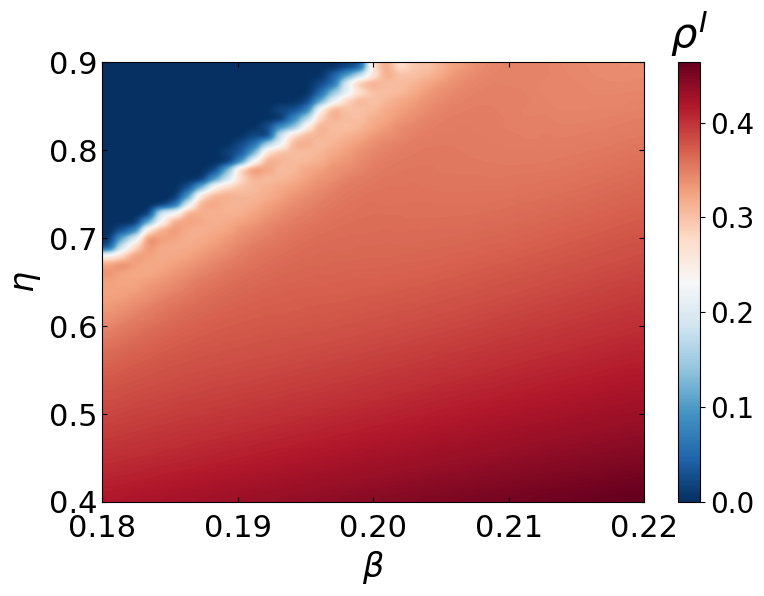

保存热力图到: ./heatmap_init0.2.pdf
正在读取: mmca_heatmap_init0.8_parallel\heatmap_mean_ss_rho_init0.8.csv


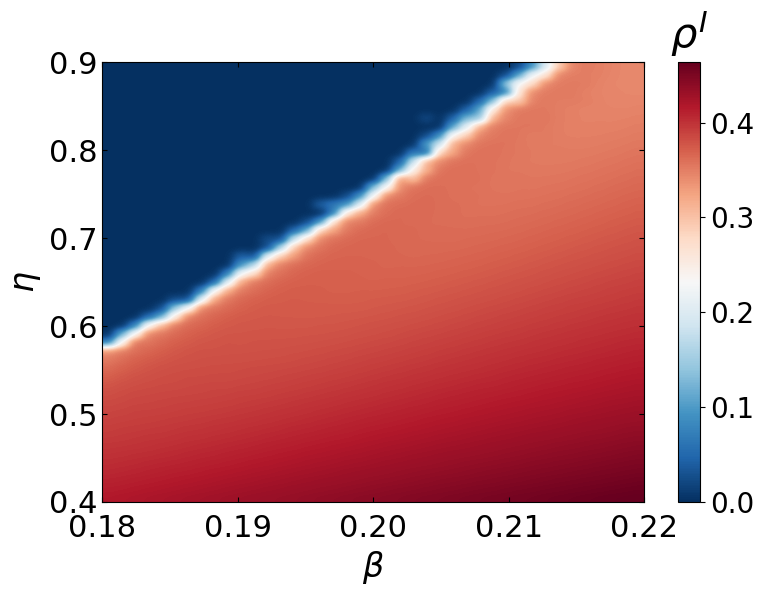

保存热力图到: ./heatmap_init0.8.pdf

所有热力图生成完成!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------- 从CSV文件读取数据并绘制热力图 ---------------------

# 定义初始感染率列表
init_fracs = [0.2, 0.8]

# 网格参数（需要与生成CSV文件时使用的参数一致）
beta_min, beta_max = 0.18, 0.22
eta_min, eta_max = 0.3, 0.8

for init_frac in init_fracs:
    # 构建CSV文件路径
    out_dir = f"mmca_heatmap_init{init_frac}_parallel"
    csv_fn = os.path.join(out_dir, f"heatmap_mean_ss_rho_init{init_frac}.csv")
    
    # 检查文件是否存在
    if not os.path.exists(csv_fn):
        print(f"警告: 文件 {csv_fn} 不存在，跳过 init_frac = {init_frac}")
        continue
    
    print(f"正在读取: {csv_fn}")
    
    # 读取CSV文件
    df_heat = pd.read_csv(csv_fn, index_col=0)
    
    # 提取热力矩阵数据
    heatmat = df_heat.values
    
    # 从索引和列名中提取eta和beta的值
    etas = df_heat.index.values.astype(float)
    betas = df_heat.columns.values.astype(float)
    
    # 画热力图
    plt.figure(figsize=(8,6))
    
    # 使用提取的eta和beta范围
    plt.imshow(heatmat, origin='lower', aspect='auto', cmap='RdBu_r', interpolation='gaussian',
               extent=[betas.min(), betas.max(), etas.min(), etas.max()])
    
    # 创建 colorbar 并设置标签及刻度字体大小
    colorbar = plt.colorbar(label='')
    colorbar.ax.tick_params(labelsize='20')
    # 移动 colorbar 标签到最上方
    colorbar.ax.set_title(r'$\rho^I$', fontsize=30, pad=10)
    
    # 设置 colorbar 的大小（高度）为原图的一半
    colorbar.ax.set_position([0.8, 0.12, 0.3, 0.75])
    
    plt.xlabel(r"$\beta$", fontsize=24)
    plt.ylabel(r"$\eta$", fontsize=24)
    
    # 美化坐标刻度：选几个刻度显示
    plt.xticks(np.linspace(betas.min(), betas.max(), 5), fontsize=22)
    plt.yticks(np.linspace(etas.min(), etas.max(), 6), fontsize=22)

        # 启用四面刻度
    plt.tick_params(
        axis='both',      # 同时控制 x 和 y 轴
        which='both',     # 同时控制主刻度和次刻度
        top=True,         # 显示顶部刻度
        right=True,       # 显示右侧刻度
        labeltop=False,   # 不显示顶部刻度标签（避免重叠）
        labelright=False,  # 不显示右侧刻度标签（避免重叠）
        direction='in',   # 刻度朝内
    )
    # ← 新增这行：专门调整x轴刻度的位置
    plt.tick_params(axis='x', pad=9)

    pdf_fn = os.path.join("./", f"heatmap_init{init_frac}.pdf")
    plt.tight_layout()
    plt.savefig(pdf_fn, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"保存热力图到: {pdf_fn}")

print("\n所有热力图生成完成!")